# $K_S^0$ proper-decay-length check with PyROOT

This notebook takes the 3D ROOT histogram shown in your screenshot,

- **x:** $m_{\pi\pi}$ [GeV/$c^2$]
- **y:** $p_T^{V0}$ [GeV/$c$]
- **z:** V0 decay radius $R$ [cm],

and transforms the decay radius to a transverse proper-decay-length estimator

$$c\tau_T \equiv R\,\frac{m}{p_T}.$$

For a correctly reconstructed $K_S^0$ sample this distribution should be approximately exponential with a characteristic scale close to the PDG value
$$c\tau(K_S^0) \simeq 2.684\;\mathrm{cm}.$$

This is the transverse analogue of the $L\,m/p$ quantity used in the ALICE lifetime/check plots.

**Reference:** ALICE, arXiv:1012.3257 and arXiv:1307.5530.


In [1]:
import ROOT as root
import math

root.gStyle.SetOptStat(0)
root.gStyle.SetOptFit(1111)
#root.gROOT.SetBatch(False)

# ------------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------------
FILE_NAME = "input/k0s_double_peak_stream_v0.root"
HIST_NAME = "h_decay_radius_vs_mass_vs_pt"

# K0S constants
K0S_MASS = 0.497611       # GeV/c^2
K0S_CTAU = 2.6844         # cm

# Mass window used for the lifetime projection
MASS_MIN = 0.485
MASS_MAX = 0.510

# Optional pT range. Use None for the full histogram range.
PT_MIN = None
PT_MAX = None

# Output c*tau range and binning
CTAU_MIN = 0.0
CTAU_MAX = 50.0
N_CTAU_BINS = 200


Welcome to JupyROOT 6.30/06


## Open the ROOT file and locate the TH3

The recursive search is useful if the histogram sits inside a ROOT directory rather than at the top level.


In [2]:
def find_object_recursive(directory, object_name):
    obj = directory.Get(object_name)
    if obj:
        return obj

    for key in directory.GetListOfKeys():
        item = key.ReadObj()
        if item.InheritsFrom("TDirectory"):
            found = find_object_recursive(item, object_name)
            if found:
                return found
    return None

f = root.TFile.Open(FILE_NAME, "READ")
if not f or f.IsZombie():
    raise RuntimeError(f"Cannot open {FILE_NAME}")

h3 = find_object_recursive(f, HIST_NAME)
if not h3:
    raise RuntimeError(f"Could not find histogram '{HIST_NAME}'")

if not h3.InheritsFrom("TH3"):
    raise TypeError(f"{HIST_NAME} is not a TH3")

print("Found:", h3.GetName())
print("Entries:", h3.GetEntries())
print("X axis:", h3.GetXaxis().GetTitle())
print("Y axis:", h3.GetYaxis().GetTitle())
print("Z axis:", h3.GetZaxis().GetTitle())


Found: h_decay_radius_vs_mass_vs_pt
Entries: 2071715.0
X axis:  m_{#pi#pi} [GeV/c^{2}]
Y axis:  p_{T}^{V0} [GeV/c]
Z axis:  decay radius [cm]


## Replot the original $m_{\pi\pi}$--$p_T$--$R$ distribution


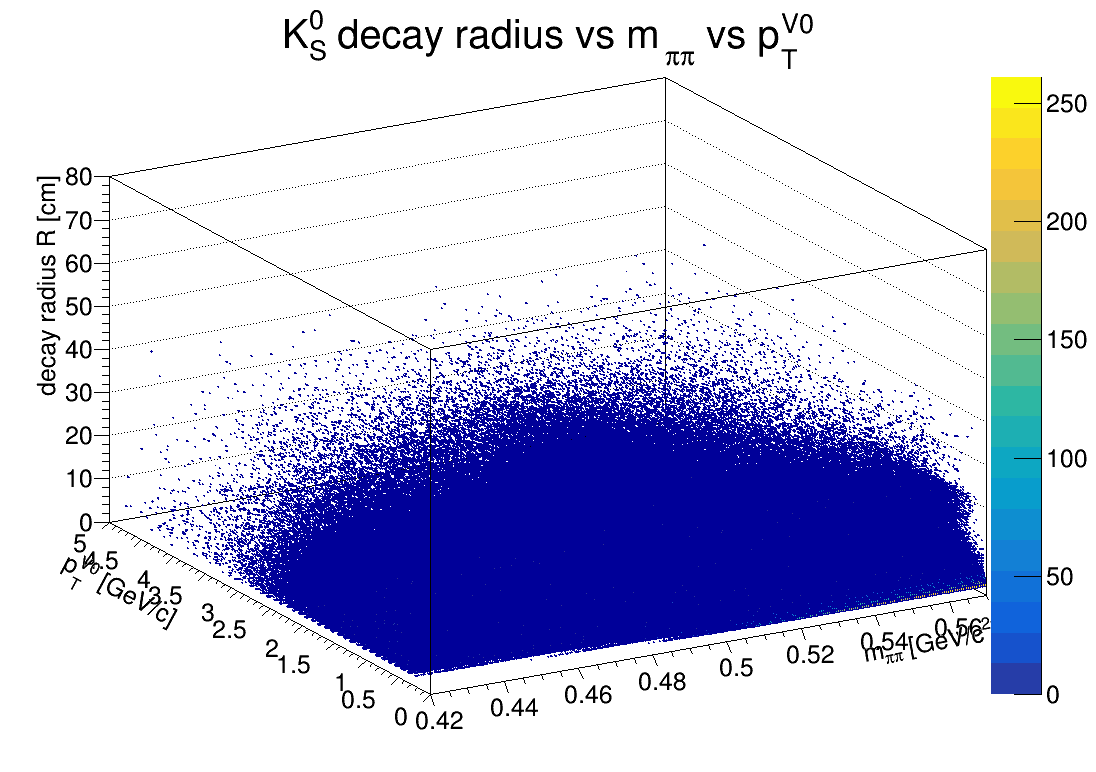

In [3]:
c_original = root.TCanvas("c_original", "Original V0 distribution", 1100, 800)
h3.SetTitle("K^{0}_{S} decay radius vs m_{#pi#pi} vs p_{T}^{V0};m_{#pi#pi} [GeV/c^{2}];p_{T}^{V0} [GeV/c];decay radius R [cm]")
h3.Draw("BOX2Z")
c_original.Draw()


## Convert $R$ into $R\,m/p_T$

For every occupied TH3 bin we use the bin centers

$$c\tau_T = R\frac{m_{\pi\pi}}{p_T^{V0}},$$

and preserve the original bin content as the weight.  This produces:

1. a **mass vs. $c\tau_T$** histogram for seeing the $K_S^0$ band, and
2. a **1D $c\tau_T$ distribution** inside the chosen $K_S^0$ mass window.


In [4]:
xax = h3.GetXaxis()   # mass
yax = h3.GetYaxis()   # pT
zax = h3.GetZaxis()   # R

h_mass_ctau = root.TH2D(
    "h_mass_ctau",
    "K^{0}_{S}: transverse proper decay length;m_{#pi#pi} [GeV/c^{2}];R m_{#pi#pi}/p_{T}^{V0} [cm]",
    xax.GetNbins(), xax.GetXmin(), xax.GetXmax(),
    N_CTAU_BINS, CTAU_MIN, CTAU_MAX
)

h_ctau_k0s = root.TH1D(
    "h_ctau_k0s",
    f"K^{{0}}_{{S}} candidate proper decay length, {MASS_MIN:.3f}<m_{{#pi#pi}}<{MASS_MAX:.3f} GeV/c^{{2}};R m_{{#pi#pi}}/p_{{T}}^{{V0}} [cm];Counts",
    N_CTAU_BINS, CTAU_MIN, CTAU_MAX
)

for ix in range(1, xax.GetNbins() + 1):
    mass = xax.GetBinCenter(ix)
    for iy in range(1, yax.GetNbins() + 1):
        pt = yax.GetBinCenter(iy)
        if pt <= 0:
            continue
        if PT_MIN is not None and pt < PT_MIN:
            continue
        if PT_MAX is not None and pt >= PT_MAX:
            continue

        for iz in range(1, zax.GetNbins() + 1):
            weight = h3.GetBinContent(ix, iy, iz)
            if weight <= 0:
                continue

            radius = zax.GetBinCenter(iz)
            ctau = radius * mass / pt

            h_mass_ctau.Fill(mass, ctau, weight)

            if MASS_MIN <= mass < MASS_MAX:
                h_ctau_k0s.Fill(ctau, weight)

print("K0S-window weighted entries:", h_ctau_k0s.Integral())


K0S-window weighted entries: 496082.0


## Mass vs. rescaled decay length

The vertical lines mark the mass slice used below.


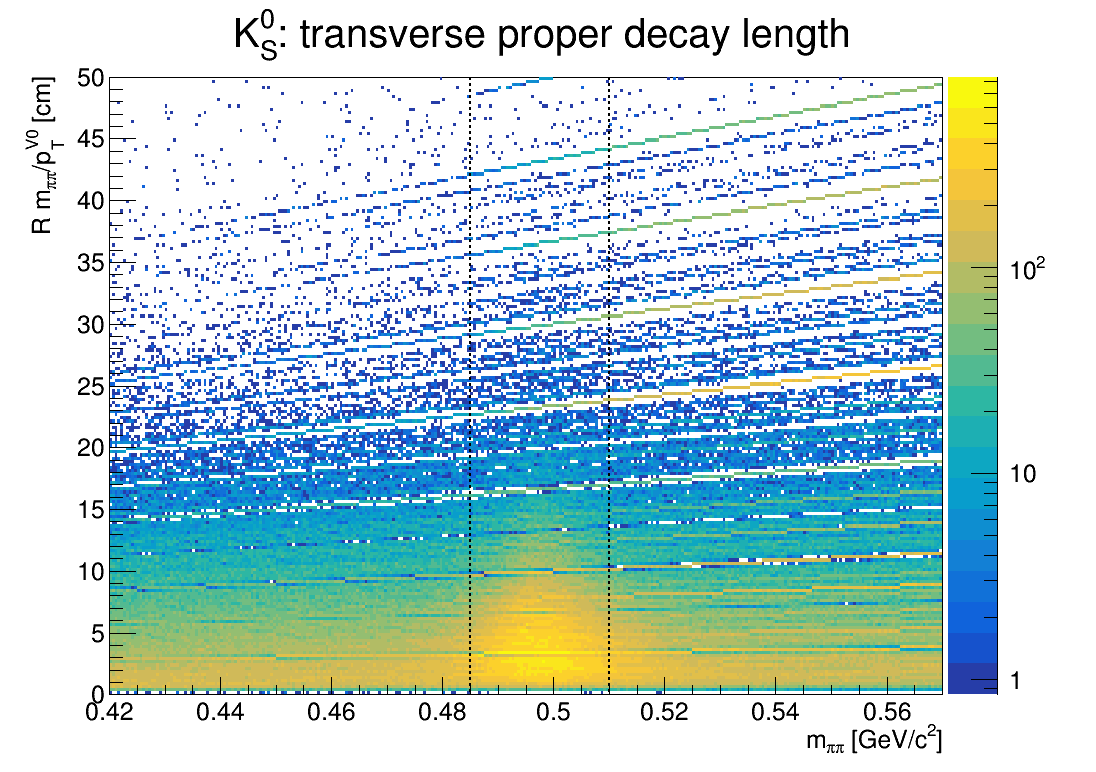

In [5]:
c_mass_ctau = root.TCanvas("c_mass_ctau", "Mass vs c tau", 1100, 800)
c_mass_ctau.SetRightMargin(0.14)
c_mass_ctau.SetLogz()

h_mass_ctau.Draw("COLZ")

l1 = root.TLine(MASS_MIN, CTAU_MIN, MASS_MIN, CTAU_MAX)
l2 = root.TLine(MASS_MAX, CTAU_MIN, MASS_MAX, CTAU_MAX)
l1.SetLineStyle(2)
l2.SetLineStyle(2)
l1.SetLineWidth(2)
l2.SetLineWidth(2)
l1.Draw()
l2.Draw()

c_mass_ctau.Draw()


## $K_S^0$ mass slice: compare to the known lifetime

For a pure sample without acceptance/reconstruction effects,

$$N(c\tau) \propto e^{-c\tau/c\tau_{K_S^0}}.$$

The dashed reference curve below has its slope fixed to the PDG $K_S^0$ value.  Its normalization is matched to the histogram; this is intended as a visual lifetime check, not an efficiency-corrected lifetime measurement.


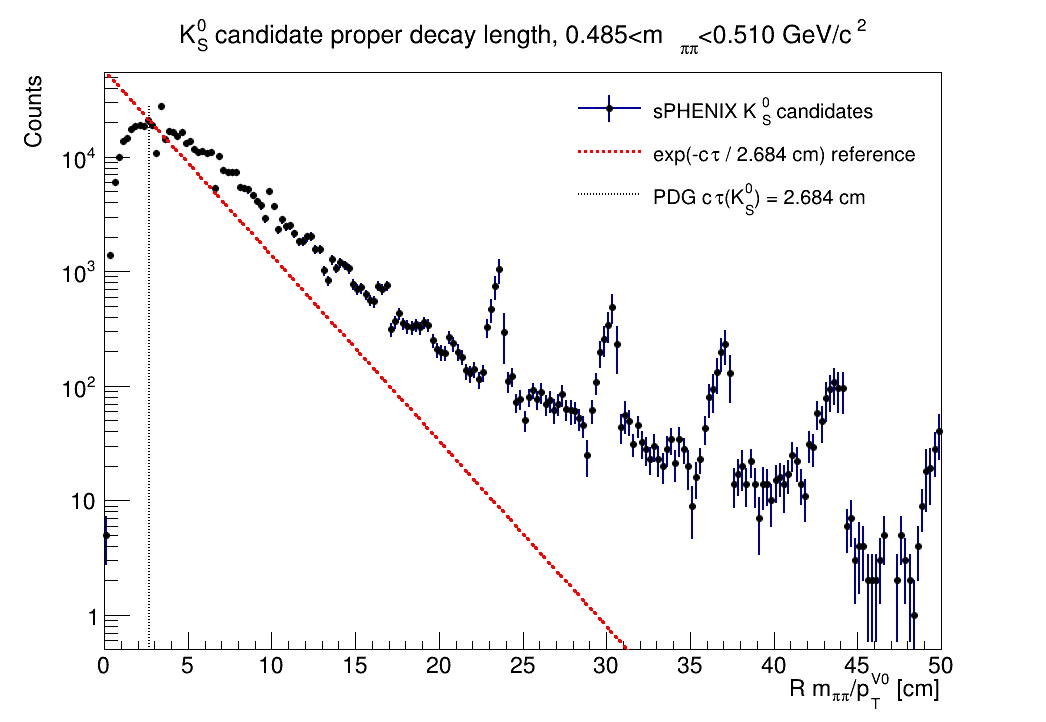

In [6]:
c_ctau = root.TCanvas("c_ctau", "K0S c tau projection", 1050, 750)
c_ctau.SetLogy()

h_ctau_k0s.SetMarkerStyle(20)
h_ctau_k0s.SetMarkerSize(0.8)
h_ctau_k0s.SetLineWidth(2)
h_ctau_k0s.SetMinimum(0.5)
h_ctau_k0s.Draw("E")

# Reference exponential with fixed PDG c*tau.
# Choose a normalization point away from the first bins, which can be
# strongly affected by the secondary-vertex fiducial cut / efficiency.
norm_x = max(CTAU_MIN + 1.0, K0S_CTAU)
norm_bin = h_ctau_k0s.FindBin(norm_x)
norm_y = h_ctau_k0s.GetBinContent(norm_bin)
if norm_y <= 0:
    norm_y = h_ctau_k0s.GetMaximum()

A = norm_y * math.exp(norm_x / K0S_CTAU)
f_pdg = root.TF1("f_pdg", f"{A}*exp(-x/{K0S_CTAU})", CTAU_MIN, CTAU_MAX)
f_pdg.SetLineStyle(2)
f_pdg.SetLineWidth(3)
f_pdg.Draw("SAME")

# Vertical line at one K0S mean proper decay length
l_ctau = root.TLine(K0S_CTAU, 0.5, K0S_CTAU, max(1.0, h_ctau_k0s.GetMaximum()))
l_ctau.SetLineStyle(3)
l_ctau.SetLineWidth(2)
l_ctau.Draw()

leg = root.TLegend(0.54, 0.70, 0.88, 0.88)
leg.SetBorderSize(0)
leg.AddEntry(h_ctau_k0s, "sPHENIX K^{0}_{S} candidates", "lep")
leg.AddEntry(f_pdg, "exp(-c#tau / 2.684 cm) reference", "l")
leg.AddEntry(l_ctau, "PDG c#tau(K^{0}_{S}) = 2.684 cm", "l")
leg.Draw()

c_ctau.Draw()


## Optional: fit the visible exponential tail

Do **not** blindly fit from zero.  The low-$R$ region is usually distorted by V0 reconstruction efficiency and any minimum decay-radius selection.  Set `FIT_MIN` above the turn-on region seen in your data.


Fitted c*tau = 3.5906 +/- 0.0334 cm
PDG K0S c*tau = 2.6844 cm
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      352.426
NDf                       =           58
Edm                       =  8.90048e-07
NCalls                    =           81
Normalization             =      52517.6   +/-   1483.89     
c#tau [cm]                =      3.59065   +/-   0.0333962   


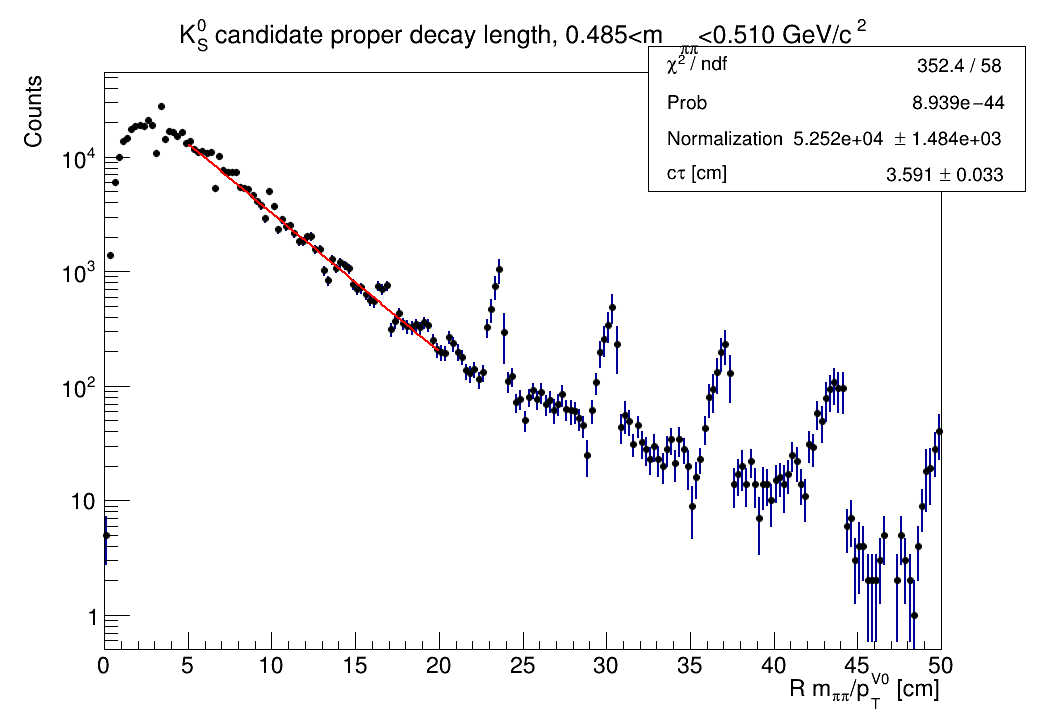

In [7]:
FIT_MIN = 5.0
FIT_MAX = 20.0

f_lifetime = root.TF1("f_lifetime", "[0]*exp(-x/[1])", FIT_MIN, FIT_MAX)
f_lifetime.SetParameters(h_ctau_k0s.GetMaximum(), K0S_CTAU)
f_lifetime.SetParNames("Normalization", "c#tau [cm]")

fit_result = h_ctau_k0s.Fit(f_lifetime, "SR")
print(f"Fitted c*tau = {f_lifetime.GetParameter(1):.4f} +/- {f_lifetime.GetParError(1):.4f} cm")
print(f"PDG K0S c*tau = {K0S_CTAU:.4f} cm")

c_fit = root.TCanvas("c_fit", "Lifetime fit", 1050, 750)
c_fit.SetLogy()
h_ctau_k0s.Draw("E")
f_lifetime.Draw("SAME")
c_fit.Draw()


## Optional: compare several $p_T$ slices

This is useful because a correct $R\,m/p_T$ scaling should make the characteristic decay scale much less dependent on $p_T$ than the raw decay-radius distribution.


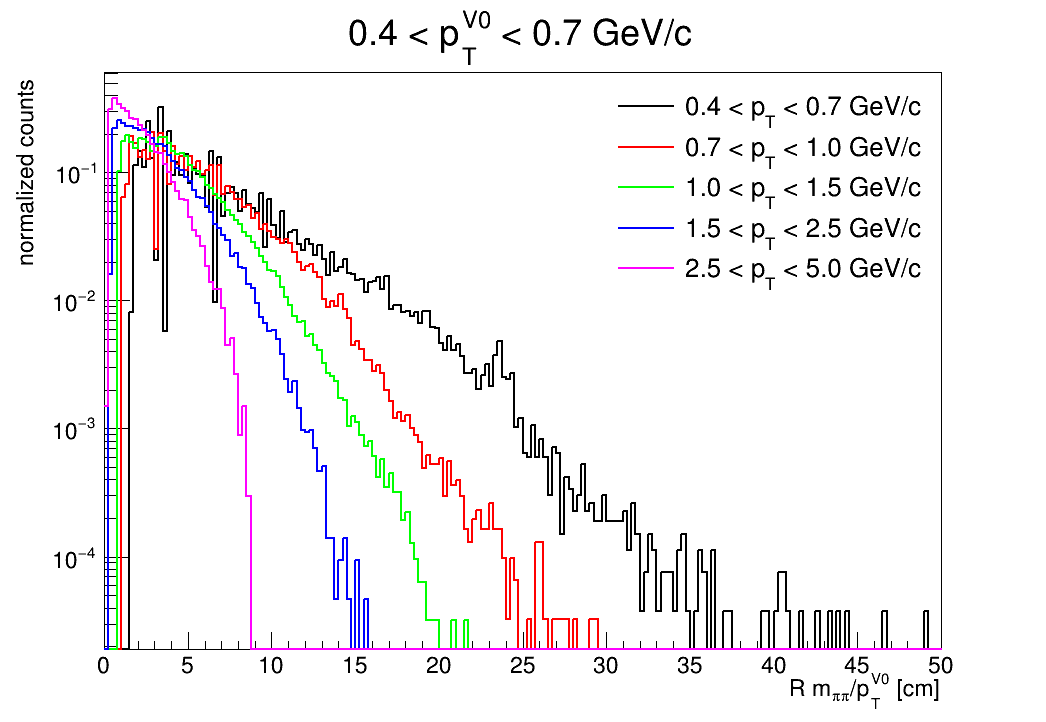

In [8]:
PT_SLICES = [(0.4, 0.7), (0.7, 1.0), (1.0, 1.5), (1.5, 2.5), (2.5, 5.0)]

slice_hists = []
for i, (pt_lo, pt_hi) in enumerate(PT_SLICES):
    h = root.TH1D(
        f"h_ctau_pt_{i}",
        f"{pt_lo:.1f} < p_{{T}}^{{V0}} < {pt_hi:.1f} GeV/c;R m_{{#pi#pi}}/p_{{T}}^{{V0}} [cm];normalized counts",
        N_CTAU_BINS, CTAU_MIN, CTAU_MAX
    )

    for ix in range(1, xax.GetNbins() + 1):
        mass = xax.GetBinCenter(ix)
        if not (MASS_MIN <= mass < MASS_MAX):
            continue
        for iy in range(1, yax.GetNbins() + 1):
            pt = yax.GetBinCenter(iy)
            if not (pt_lo <= pt < pt_hi) or pt <= 0:
                continue
            for iz in range(1, zax.GetNbins() + 1):
                weight = h3.GetBinContent(ix, iy, iz)
                if weight <= 0:
                    continue
                radius = zax.GetBinCenter(iz)
                h.Fill(radius * mass / pt, weight)

    if h.Integral() > 0:
        h.Scale(1.0 / h.Integral("width"))
    h.SetLineWidth(2)
    slice_hists.append((h, pt_lo, pt_hi))

c_slices = root.TCanvas("c_slices", "pT slices", 1050, 750)
c_slices.SetLogy()

leg2 = root.TLegend(0.58, 0.60, 0.88, 0.88)
leg2.SetBorderSize(0)

for i, (h, pt_lo, pt_hi) in enumerate(slice_hists):
    h.SetLineColor(i + 1 if i + 1 != 5 else 6)
    h.SetMarkerColor(h.GetLineColor())
    h.Draw("HIST" if i == 0 else "HIST SAME")
    leg2.AddEntry(h, f"{pt_lo:.1f} < p_{{T}} < {pt_hi:.1f} GeV/c", "l")

leg2.Draw()
c_slices.Draw()


### Interpretation

If the candidates are dominated by real $K_S^0$ decays, the $R\,m/p_T$ distributions from different $p_T$ slices should line up much better than the corresponding raw-$R$ distributions.  A deficit at small $c\tau_T$ is expected if you impose a minimum V0 decay radius or if the reconstruction efficiency falls rapidly close to the primary vertex.

For a final physics lifetime extraction you would want an efficiency correction versus decay radius/$c\tau$ and, ideally, sideband subtraction under the $K_S^0$ mass peak.  For a reconstruction QA plot, the notebook above is already a useful direct comparison to the ALICE-style $Lm/p$ distribution.
